<a href="https://colab.research.google.com/github/rishitharee24-create/maths/blob/main/Unit5q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Circuit resonant frequency f_res = 50.33 Hz
Driving frequencies: 15.92 Hz and 63.66 Hz


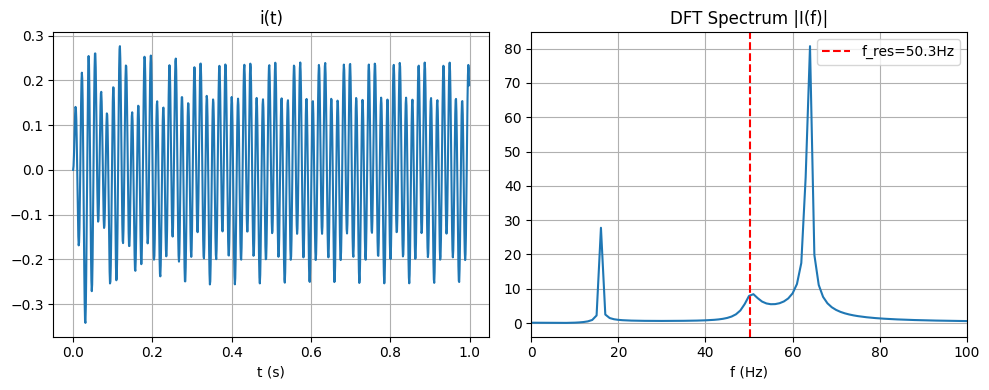

Dominant frequency in response: 64.00 Hz


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

R, L, C = 2, 0.1, 100e-6

def v(t):
    return 5*np.sin(100*t) + 3*np.sin(400*t)
def vprime(t, dt=1e-6):
    return (v(t+dt)-v(t-dt))/(2*dt)

def rlc_ode(y, t):
    i, didt = y
    d2i = (vprime(t) - R*didt - i/C) / L
    return [didt, d2i]

fs = 1000
t = np.arange(0, 1, 1/fs)
sol = odeint(rlc_ode, [0, 0], t)
i_t = sol[:, 0]

# DFT
I_f = np.fft.rfft(i_t)
freqs = np.fft.rfftfreq(len(t), 1/fs)
mag = np.abs(I_f)

# Resonant frequency of circuit
f_res = 1/(2*np.pi*np.sqrt(L*C))
print(f"Circuit resonant frequency f_res = {f_res:.2f} Hz")
print(f"Driving frequencies: {100/(2*np.pi):.2f} Hz and {400/(2*np.pi):.2f} Hz")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t, i_t); plt.title('i(t)'); plt.xlabel('t (s)'); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(freqs, mag); plt.title('DFT Spectrum |I(f)|'); plt.xlabel('f (Hz)')
plt.axvline(f_res, color='r', linestyle='--', label=f'f_res={f_res:.1f}Hz')
plt.legend(); plt.grid(True); plt.xlim(0, 100)
plt.tight_layout()
plt.savefig('p25_dft_circuit.png', dpi=120)
plt.show()

# Top frequency component
peak_idx = np.argmax(mag[1:]) + 1
print(f"Dominant frequency in response: {freqs[peak_idx]:.2f} Hz")











